In [1]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

In [2]:

# 2. Load dataset
df = pd.read_csv("kc_house_data.csv")

In [3]:

# 3. Handle missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

In [4]:
# 4. Convert categorical columns to numeric (important for XGBoost)
df = pd.get_dummies(df, drop_first=True)

In [5]:
# 5. Define features and target (change 'Price' if your target column name is different)
X = df.drop("price", axis=1)
y = df["price"]

In [6]:
# 6. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
# 7. Create XGBoost model
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [8]:

# 8. Train model
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [9]:
# 9. Make predictions
y_pred = xgb_model.predict(X_test)

In [10]:
# 10. Evaluate model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 137992.53447599817
R2 Score: 0.8740418462153327


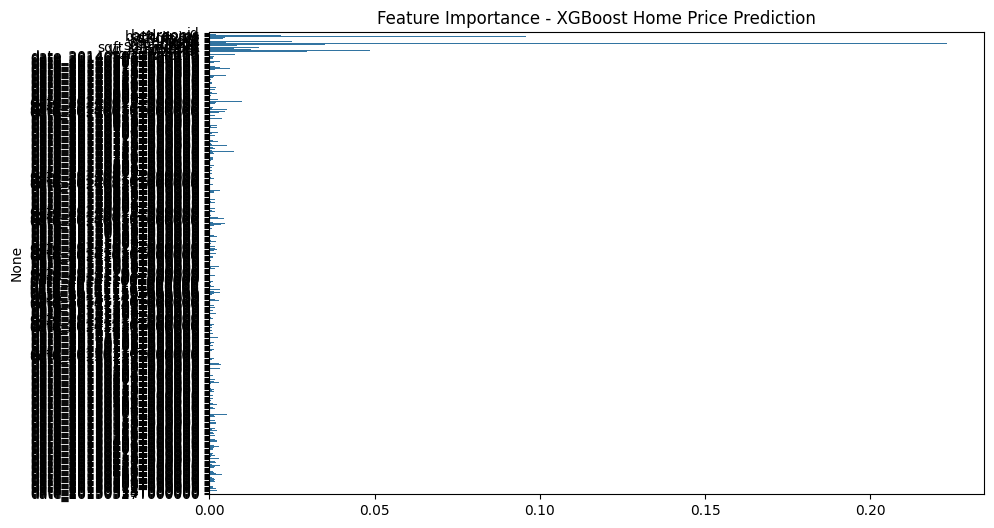

In [11]:
# 11. Feature importance plot
plt.figure(figsize=(10,6))
sns.barplot(x=xgb_model.feature_importances_, y=X.columns)
plt.title("Feature Importance - XGBoost Home Price Prediction")
plt.show()

In [12]:
# 12. Conclusion
print("Conclusion: The XGBoost model successfully predicts home prices using factors such as income, facilities, and crime rates.")



Conclusion: The XGBoost model successfully predicts home prices using factors such as income, facilities, and crime rates.
